# 01 · Breguet vs PhlyGreen

The **Breguet range equation** is the back-of-envelope tool every aircraft engineer reaches for first. Here we (1) estimate the cruise fuel fraction by hand, (2) size the *same* aircraft with PhlyGreen's full mission + weight loop, and (3) understand why the two disagree. The gap is not error — it is everything Breguet leaves out.

## 1. The Breguet range equation

In its energy form (convenient when you think in efficiencies rather than SFC):

$$ R = \frac{\eta_{\text{overall}}}{g}\, E_f\, \frac{L}{D}\, \ln\!\frac{W_0}{W_1} $$

where $E_f$ is the fuel specific energy, $\eta_{\text{overall}}=\eta_{th}\,\eta_{trans}\,\eta_{prop}$, and $W_0/W_1$ is the start/end **cruise** weight ratio. The cruise fuel fraction is $W_f/W_0 = 1 - W_1/W_0$. It assumes a *single steady cruise* at constant $L/D$ and efficiency — no climb, no descent, no reserves, no resizing.

In [1]:
# --- environment setup (educational tutorials) ---------------------------------
# These notebooks teach concepts *through* PhlyGreen. They use the real design API where
# it exists and small, clearly-labelled pedagogical proxies where it does not.
import warnings
warnings.filterwarnings("ignore")     # keep the solver's internal chatter out of the output
import numpy as np
import matplotlib.pyplot as plt

from _learning_utils import add_examples_to_path
add_examples_to_path()                # puts trunk/examples on sys.path (no absolute paths)

import PhlyGreen as pg
from PhlyGreen import postprocess as pp

from common import traditional_config
from _learning_utils import breguet_fuel_fraction, breguet_range

# Inputs consistent with the baseline turboprop (examples/common.py).
R_nm   = 750.0                # design range [nm]
R_m    = R_nm * 1852.0        # -> metres
V      = 130.0               # cruise TAS [m/s] (~Mach 0.4 at 8 km)
Ef     = 43.5e6              # Jet-A specific energy [J/kg]
eta_th, eta_trans, eta_prop = 0.22, 0.96, 0.90   # same chain as common.py
eta    = eta_th * eta_trans * eta_prop
LD     = 14.0                # representative cruise L/D for a regional turboprop

ff_breguet = breguet_fuel_fraction(R_m, V, eta, LD, Ef)
print(f'overall efficiency eta = {eta:.3f}')
print(f'Breguet cruise fuel fraction Wf/W0 = {ff_breguet:.3f}')

overall efficiency eta = 0.190
Breguet cruise fuel fraction Wf/W0 = 0.111


The hand estimate says cruise burns roughly **11% of the take-off weight** in fuel (printed above). That is the *cruise-only* fuel fraction for the assumed $L/D$ and efficiencies.

## 2. Size the same aircraft with PhlyGreen

Now run the full sizing loop: climb/descent segments, a diversion, reserves, and the iterative weight convergence. We read the *block* fuel (trip + reserves) and the mission fuel, and convert each to a fraction of take-off weight.

In [2]:
aircraft = pg.build_aircraft()
aircraft.configure(traditional_config())
r = aircraft.results()
ff_phly_block = r.block_fuel / r.WTO        # incl. reserves
ff_phly_trip  = r.Wf / r.WTO                # mission fuel only
print(f'PhlyGreen WTO            = {r.WTO:,.0f} kg')
print(f'PhlyGreen block fuel     = {r.block_fuel:,.0f} kg   (Wf/W0 = {ff_phly_block:.3f})')
print(f'PhlyGreen mission fuel   = {r.Wf:,.0f} kg   (Wf/W0 = {ff_phly_trip:.3f})')
print(f'PhlyGreen final reserve  = {r.final_reserve:,.0f} kg')

PhlyGreen WTO            = 18,327 kg
PhlyGreen block fuel     = 2,038 kg   (Wf/W0 = 0.111)
PhlyGreen mission fuel   = 1,908 kg   (Wf/W0 = 0.104)
PhlyGreen final reserve  = 130 kg


## 3. Compare

Plot the Breguet **range ⇄ fuel-fraction** curve and drop the PhlyGreen result on top. Two PhlyGreen markers are shown: *mission fuel only* (closest to Breguet's assumptions) and *block fuel* (what the aircraft actually carries, including reserves).

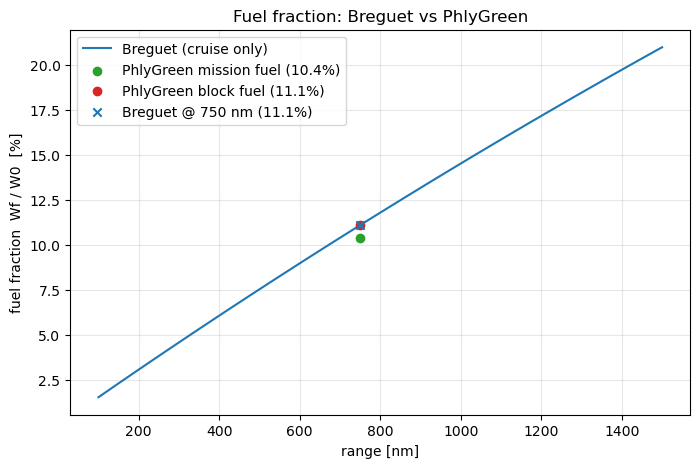

In [3]:
ranges = np.linspace(100, 1500, 60) * 1852.0
ff_curve = [breguet_fuel_fraction(R, V, eta, LD, Ef) for R in ranges]

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(ranges/1852.0, np.array(ff_curve)*100, label='Breguet (cruise only)', color='tab:blue')
ax.scatter([R_nm], [ff_phly_trip*100], color='tab:green', zorder=5,
           label=f'PhlyGreen mission fuel ({ff_phly_trip*100:.1f}%)')
ax.scatter([R_nm], [ff_phly_block*100], color='tab:red', zorder=5,
           label=f'PhlyGreen block fuel ({ff_phly_block*100:.1f}%)')
ax.scatter([R_nm], [ff_breguet*100], color='tab:blue', marker='x', zorder=5,
           label=f'Breguet @ {R_nm:.0f} nm ({ff_breguet*100:.1f}%)')
ax.set_xlabel('range [nm]'); ax.set_ylabel('fuel fraction  Wf / W0  [%]')
ax.set_title('Fuel fraction: Breguet vs PhlyGreen'); ax.grid(alpha=0.3); ax.legend()
plt.show()

In [4]:
# Compact comparison table.
rows = [('Breguet (cruise only)', ff_breguet),
        ('PhlyGreen mission fuel', ff_phly_trip),
        ('PhlyGreen block fuel',   ff_phly_block)]
print(f"{'method':28s} {'Wf/W0':>8s}")
for name, ff in rows:
    print(f'{name:28s} {ff*100:7.1f}%')

method                          Wf/W0
Breguet (cruise only)           11.1%
PhlyGreen mission fuel          10.4%
PhlyGreen block fuel            11.1%


### Why do they differ?

- **Reserves & diversion.** Breguet sized only the trip; PhlyGreen also carries diversion + final-reserve fuel — pure overhead it must lift the whole flight.
- **Climb & descent.** The climb is flown at high power and poor range efficiency; Breguet ignores it entirely.
- **Off-design $L/D$ and efficiency.** Our hand calc fixed $L/D=14$ and a single $\eta$; PhlyGreen evaluates them along the real trajectory.
- **Mass coupling.** More fuel ⇒ heavier aircraft ⇒ more drag ⇒ more fuel. PhlyGreen iterates this loop; Breguet does not.
- **Constraints.** The engine/wing are sized for take-off, climb gradient and ceiling, not for cruise economy — they may be heavier (and draggier) than a cruise-optimal design.

## Key takeaways

1. Breguet gives the *right order of magnitude* and the *right sensitivities* (range, $L/D$, efficiency, $E_f$) — invaluable for first cuts and for sanity-checking a code.
2. It systematically **under-estimates** real fuel because it omits reserves, climb/descent and mass coupling.
3. A sizing tool like PhlyGreen exists precisely to close those gaps — but it is only as trustworthy as the same assumptions Breguet exposes so clearly.

## Questions for students

1. **When is Breguet useful?** For which decisions is a 10–20% fuel error acceptable?
2. **When does it become misleading?** Think short-range missions, large reserves, steep climbs, or technologies where mass coupling is violent (batteries!).
3. **Which assumptions dominate** the Breguet–PhlyGreen gap here — reserves, climb/descent, $L/D$, or the efficiency chain? Test your guess.

## Suggested modifications

- Change `R_nm` to 300 nm and 1200 nm. Does the relative gap grow or shrink? Why?
- Sweep `LD` from 12 to 18 and overlay several Breguet curves.
- Set `config.energy.contingency_fuel = 0` and rerun PhlyGreen — how much of the gap was reserves?

---
*These tutorials are educational. Where the full PhlyGreen capability is not exposed (formal constraint feasibility, non-CO₂ climate weighting) the notebook uses a simplified, clearly-labelled proxy — read the comments before trusting any number.*